In [1]:
import parametrization, sparse_matrices, numpy as np
from numpy.linalg import norm
import visualization

In [2]:
m = parametrization.Mesh("../examples/lilium.msh")
lg = parametrization.LocalGlobalParametrizer(m, parametrization.lscm(m))

In [3]:
for i in range(1000):
    lg.runIteration()
lg.energy()

0.014060518508923881

In [4]:
lg.alphaMin = 1.24
lg.alphaMax = np.pi / 2
lg.energy()

0.1157939225140533

In [5]:
lg.runIteration()
lg.energy()

0.007789613395431319

In [6]:
for i in range(5000):
    lg.runIteration()
lg.energy()

7.6256284961081605e-06

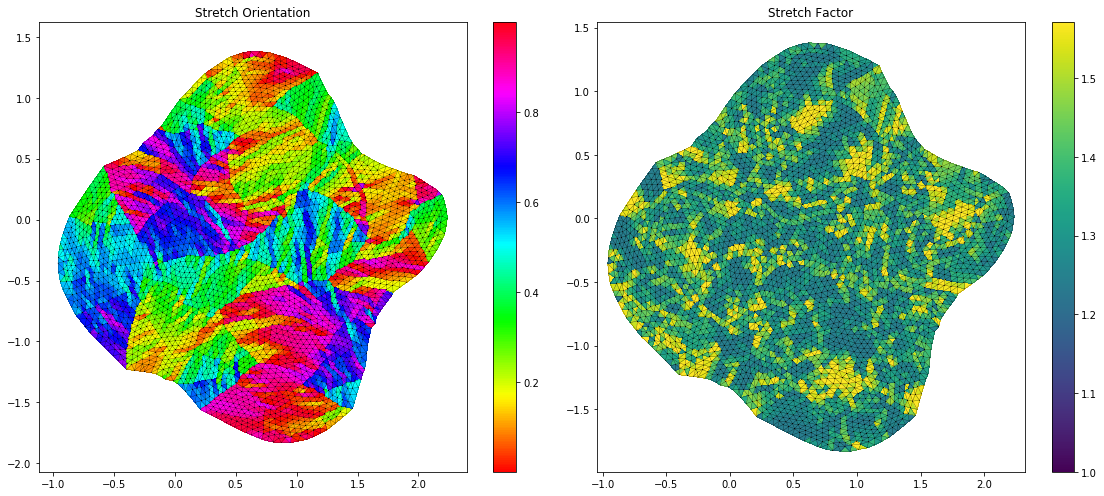

In [27]:
visualization.visualize(lg)

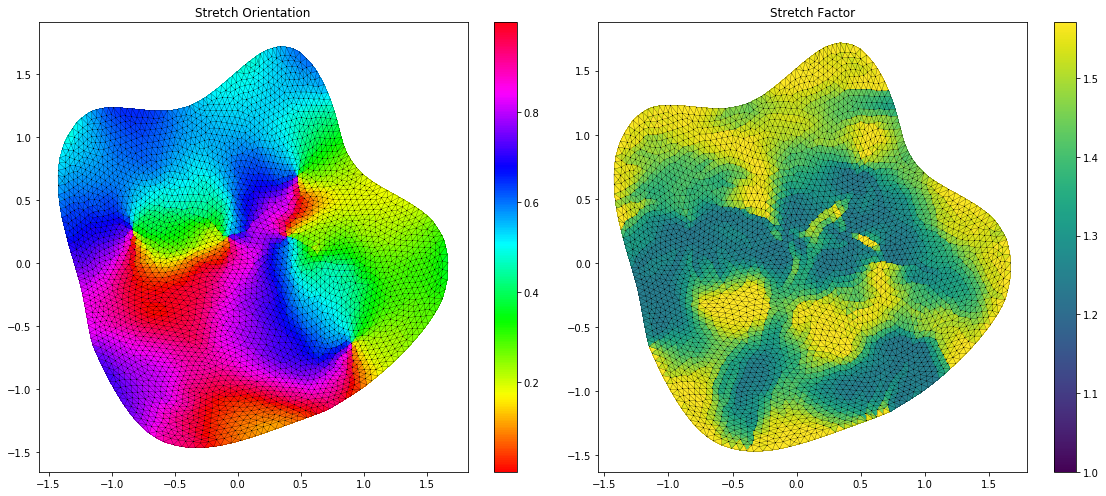

In [194]:
visualization.visualize(rparam3)

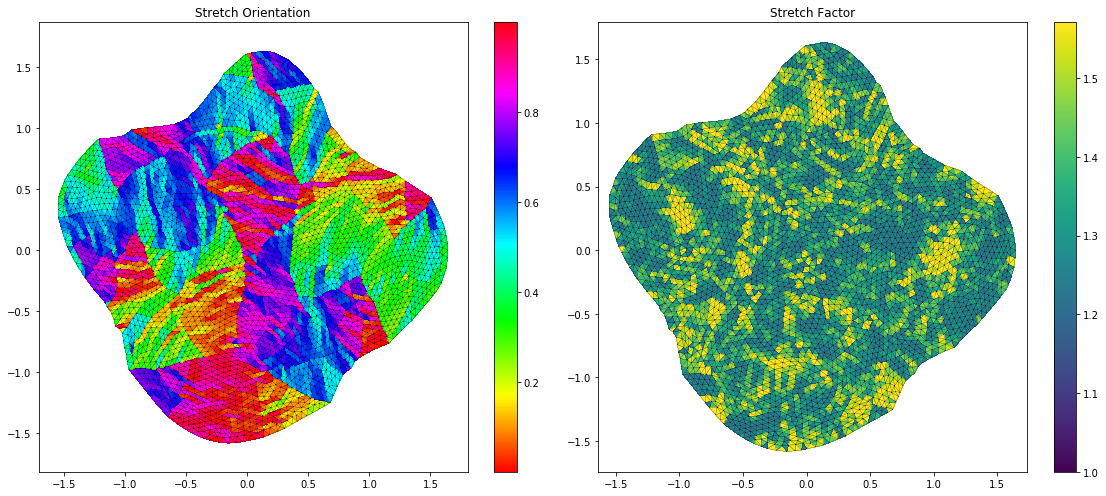

In [28]:
visualization.visualize(rparam)

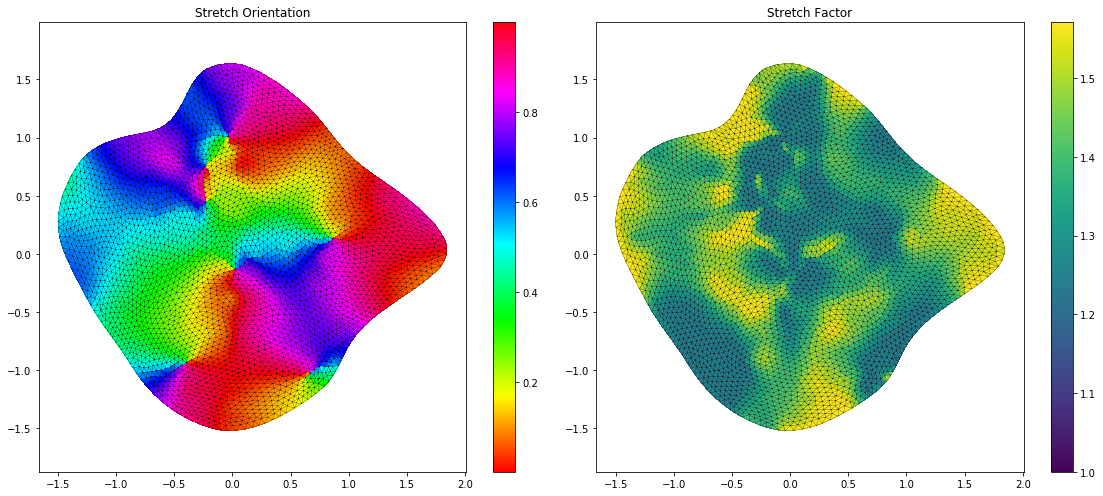

In [20]:
visualization.visualize(rparam)

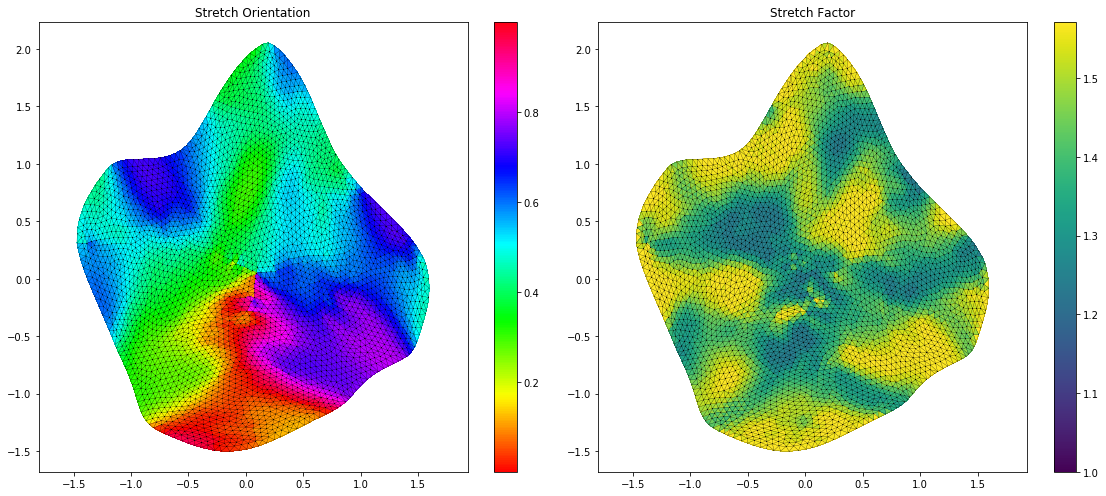

In [28]:
visualization.visualize(rparam)

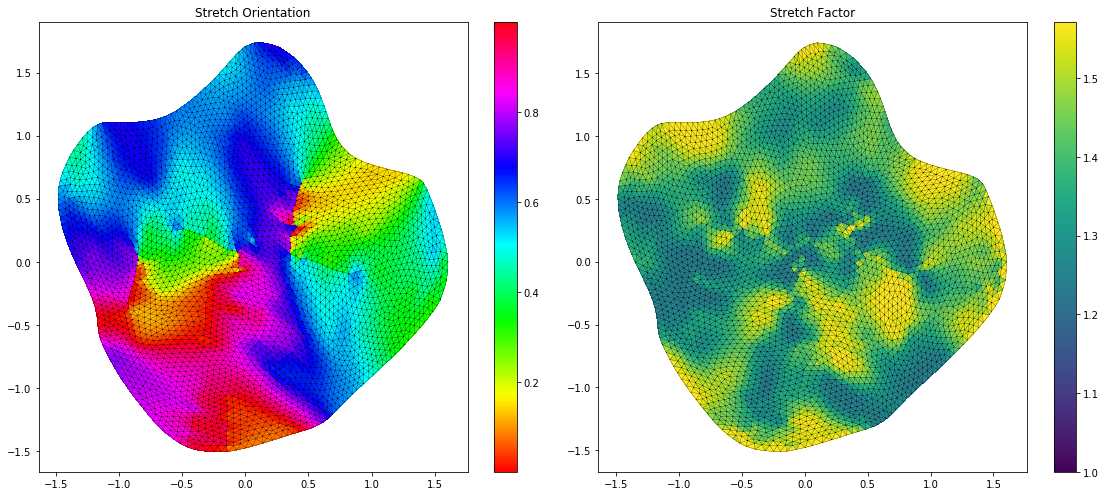

In [9]:
visualization.visualize(rparam)

In [7]:
rparam = parametrization.RegularizedParametrizerSVD(lg)
rparam.alphaRegW = 1e-6
rparam.phiRegW = 1e-6

In [8]:
rparam.phiRegW = 0
rparam.alphaRegW = 0

In [84]:
rparam.phiRegW = 1
rparam.alphaRegW = 1e-6
rparam.phiRegP = 1.0

In [73]:
rparam.alphaMin = 1.24

In [10]:
rparam.energy()

4.345593606276358e-05

In [11]:
rparam.energy(parametrization.RegularizedParametrizerSVD.EnergyType.Fitting)

1.3769627662577349e-05

In [16]:
sigma1 = rparam.getMinSingularValues()

In [14]:
sigma1 = parametrization.RegularizedParametrizerSVD(lg).getMinSingularValues()

In [51]:
rparam.energy()

308.5000637886659

In [9]:
np.min(rparam.getAlphas()), np.max(rparam.getAlphas())

(1.2330298805276771, 1.5735913751789308)

In [11]:
rparam.phiRegW = rparam.alphaRegW = 0.0

In [8]:
parametrization.regularized_parametrization_knitro(rparam, 600, rparam.rigidMotionPinVars)

In [8]:
# My newton solver makes very slow progress due to many variables entering working set.
# Also, the energy appears to be nonconvex even quite close to the optimum...
opts = parametrization.NewtonOptimizerOptions()
opts.useIdentityMetric = True
opts.beta = 1e-4
opts.niter = 600
parametrization.benchmark_reset()
cr = parametrization.regularized_parametrization_newton(rparam, rparam.rigidMotionPinVars, opts)
parametrization.benchmark_report()

Newton iterations	43.2845	1
    Newton iterate	43.2833	594
        Backtracking	1.26729	593
            Update SVD Sensitivities	0.427452	1060
        Compute descent direction	40.5915	593
            newton_step	40.5827	593
                Newton solve	23.1709	1401
                    CHOLMOD Numeric Factorize	21.8173	1401
                    Solve	0.734535	593
                        CHOLMOD Backsub	0.725214	593
                hessEval	17.3788	593
        RegularizedParametrizerSVD gradient	1.05762	594
Update SVD Sensitivities	0.000360012	1
CHOLMOD Symbolic Factorize	0.00943184	1
Full time	43.3078


In [21]:
# prevent knitro from perturbing starting point (needed for parametrization.RegularizedParametrizer)
# rparam.alphaMin = rparam.alphaMin - 1e-4
# rparam.alphaMax = rparam.alphaMax + 1e-4
# parametrization.regularized_parametrization_knitro(rparam, 100, rparam.rigidMotionPinVars)

SyntaxError: positional argument follows keyword argument (<ipython-input-21-bbcf8707e4fb>, line 4)

In [65]:
perturb = np.random.uniform(low=-1,high=1, size=rparam.numVars())

In [90]:
import fd_validation
fd_validation.validateGrad(rparam, fd_eps=1e-8,
                           xeval=rparam.getVars() + 1e-3 * np.random.uniform(low=-1, high=1, size=rparam.numVars()),
                           perturb=perturb[0:rparam.numVars()])

(-8259.89473298705, -8259.89474981839)

In [109]:
fd_validation.validateHessian(rparam, fd_eps=1e-9)

(1.0006086381637789,
 array([-1493.0566099 , -4270.95719857, -6103.32592643, ...,
          699.36852398, -1971.03218014,  2723.05916837]),
 array([-1493.05675042, -4270.9574568 , -6103.32589163, ...,
          699.36870162, -1971.03211337,  2723.05913742]))

In [112]:
H_err = fd_validation.validateHessian(rparam, fd_eps=1e-9,
                                      perturb=perturb)
fd_delta_grad, an_delta_grad = H_err[1:]
H_err

(1.0023080492136944,
 array([  -189.77575778,   5108.37418943,    281.13436379, ...,
         -5461.67824123,   -950.26274494, -13976.95677241]),
 array([  -189.77598028,   5108.37416153,    281.13406188, ...,
         -5461.67858545,   -950.26262241, -13976.95738091]))

In [113]:
worst = np.argmax(np.abs(an_delta_grad - fd_delta_grad))
(an_delta_grad[worst-2:worst+2], fd_delta_grad[worst-2:worst+2])

(array([1.77576711e+03, 3.39587350e+03, 9.27864189e+11, 2.91698744e+04]),
 array([ 1.77576562e+03,  3.39587228e+03, -5.32623585e+14,  2.91698765e+04]))